In [ ]:
%pip install bertviz
!git clone https://github.com/Data-Science-Group-Attoworld/explainable_dl_for_unstructured_data.git
%cd /content/explainable_dl_for_unstructured_data/nlp_explainabilty

# Understanding BERT on a Simple Medical Text Example

In this notebook, we follow one simple question:

**Can BERT recognize whether a sentence contains medical information?**

We will go step by step:

* First, we load a pretrained BERT model.
* We test it before training, to see that the first prediction is only a guess.
* Then we look at how text is transformed into tokens, and numerical vectors.
* We show that words are no longer handled as text, but as numerical representations.
* We compare some token vectors to see which words look similar to BERT.
* After that, we fine-tune the model on labeled medical examples.
* Finally, we test the same sentences again and look inside BERT with attention.

The goal is not only to get a prediction, but to understand what happens to a sentence inside the model.


In [3]:
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from torch.optim import AdamW
import os
from torch.nn.functional import cosine_similarity
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

## Loading BERT

In [4]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=2, attn_implementation="eager"
).to(device)

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased", do_lower_case=True)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### What does the warning tell us?

* BERT already knows many general patterns of English text.

* It can turn a sentence into a useful numerical representation.

* We add a small decision layer on top.

* This layer should decide whether the sentence contains medical information.

  * `0 = General information`
  * `1 = Medical information`

* At this point, this decision layer is still untrained.

* Therefore, before fine-tuning, the prediction is only a random guess.


In [5]:
# Test sentences used throughout the notebook
test_sentence_medical = "The young female patient suffers from chronic headaches."
test_sentence_general = (
    "The hospital's new meal plan is a real headache for the kitchen staff."
)

test_sentences = [
    ("Medical context", test_sentence_medical),
    ("General context", test_sentence_general),
]

sentence_names = [name for name, _ in test_sentences]
sentences = [sentence for _, sentence in test_sentences]

label_names = {
    0: "General information",
    1: "Medical information",
}

target_token = "headache"

# Tokenize once and reuse throughout the notebook
test_encoding = tokenizer(
    sentences,
    return_tensors="pt",
    padding=True,
    truncation=True,
)

test_input_ids = test_encoding["input_ids"].to(device)
test_attention_mask = test_encoding["attention_mask"].to(device)

test_tokens_by_sentence = [
    tokenizer.convert_ids_to_tokens(test_input_ids[i].cpu())
    for i in range(len(sentences))
]

### First prediction: before learning the task

* We first test the model before training it on our examples.
* BERT can already read the sentence and create a representation.
* However, the final decision layer has not learned our labels yet.
* Therefore, this first output is useful as a baseline, but not as a real prediction.
* After fine-tuning, we will run the same two sentences again.


In [6]:
def print_predictions(
    model, input_ids, attention_mask, test_sentences, label_names, title
):
    model.eval()

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

    probabilities = torch.nn.functional.softmax(logits, dim=1)
    predicted_classes = torch.argmax(probabilities, dim=1)

    print(title)
    print("=" * 70)

    for i, (sentence_type, sentence) in enumerate(test_sentences):
        predicted_class = predicted_classes[i].item()
        probs = probabilities[i].cpu().numpy()

        general_prob = probs[0] * 100
        medical_prob = probs[1] * 100

        print(f"{sentence_type}")
        print(f"Sentence: {sentence}")
        print()
        print("Predicted probabilities:")
        print(f"  General information: {general_prob:.1f}%")
        print(f"  Medical information: {medical_prob:.1f}%")
        print()
        print(f"Final prediction: {predicted_class} ({label_names[predicted_class]})")
        print("-" * 70)


print_predictions(
    model,
    test_input_ids,
    test_attention_mask,
    test_sentences,
    label_names,
    title="Prediction before fine-tuning",
)

Prediction before fine-tuning
Medical context
Sentence: The young female patient suffers from chronic headaches.

Predicted probabilities:
  General information: 45.4%
  Medical information: 54.6%

Final prediction: 1 (Medical information)
----------------------------------------------------------------------
General context
Sentence: The hospital's new meal plan is a real headache for the kitchen staff.

Predicted probabilities:
  General information: 47.7%
  Medical information: 52.3%

Final prediction: 1 (Medical information)
----------------------------------------------------------------------


## From text to BERT input

* The tokenizer prepares the sentences for BERT.
* It splits the text into smaller pieces called tokens.
* The model does not continue with the original words, but with numerical representations.


In [7]:
dfs = []

for i, name in enumerate(sentence_names):
    input_ids_one = test_input_ids[i].cpu().tolist()
    attention_mask_one = test_attention_mask[i].cpu().tolist()
    tokens = test_tokens_by_sentence[i]

    df_i = pd.DataFrame(
        {
            f"{name} token": tokens,
            f"{name} attention_mask": attention_mask_one,
        }
    )

    dfs.append(df_i)

token_table = pd.concat(dfs, axis=1)

token_table

,Medical context token,Medical context attention_mask,General context token,General context attention_mask
0,[CLS],1,[CLS],1
1,the,1,the,1
2,young,1,hospital,1
3,female,1,',1
4,patient,1,s,1
5,suffers,1,new,1
6,from,1,meal,1
7,chronic,1,plan,1
8,headache,1,is,1
9,##s,1,a,1


### Why do we see `[PAD]` tokens?

* The two sentences have different lengths.
* To process them together, BERT needs them to have the same length.
* The shorter sentence is filled up with `[PAD]` tokens.
* `[PAD]` tokens are only technical placeholders.
* Their `attention_mask` is `0`, so BERT ignores them.
* Real tokens have `attention_mask = 1`, so BERT uses them.


### How are the words represented?

* An embedding is a numerical profile of a token.
* In this BERT model, each token becomes a vector with 768 numbers.


In [8]:
model.eval()

with torch.no_grad():
    lookup_embeddings = (
        model.get_input_embeddings()(test_input_ids.to(device)).detach().cpu()
    )

In [9]:
def embedding_preview_table(tokens_to_show, sentence_idx=0, n_dims=12):
    rows = []

    tokens = test_tokens_by_sentence[sentence_idx]

    for token_to_find in tokens_to_show:
        token_idx = tokens.index(token_to_find)
        vector = lookup_embeddings[sentence_idx, token_idx].cpu().numpy()

        rows.append(
            {
                "token": token_to_find,
                "token_position": token_idx,
                "embedding_preview": "["
                + ", ".join([f"{x:.3f}" for x in vector[:n_dims]])
                + ", ...]",
                "full_vector_length": len(vector),
            }
        )

    return pd.DataFrame(rows)


embedding_preview_table(
    tokens_to_show=["headache", "patient", "chronic"], sentence_idx=0, n_dims=12
)

,token,token_position,embedding_preview,full_vector_length
0,headache,8,"[-0.059, 0.008, -0.066, -0.036, -0.068, -0.084...",768
1,patient,4,"[-0.045, -0.042, 0.001, -0.019, 0.011, 0.006, ...",768
2,chronic,7,"[-0.043, -0.009, -0.016, -0.032, -0.018, -0.01...",768


### Why do we use embeddings?

* These vectors place tokens in a high-dimensional embedding space.
* Tokens with similar meanings or usage patterns tend to point in similar directions.
* This means that words can have a measurable similarity, not just a symbolic identity.
* Cosine similarity allows us to compare the direction of two token vectors.
* Higher cosine similarity means that the token embeddings are more similar.
* At this stage, we are looking at the initial lookup embeddings.
* Later, BERT updates these representations using the full sentence context.


In [10]:
tokens_all = []
embeddings_all = []

skip_tokens = ["[CLS]", "[SEP]", "[PAD]", "."]

for sent_idx, sentence_name in enumerate(sentence_names):
    mask = test_attention_mask[sent_idx].cpu().tolist()
    tokens = test_tokens_by_sentence[sent_idx]

    for token, mask_value, embedding in zip(tokens, mask, lookup_embeddings[sent_idx]):
        if mask_value == 1 and token not in skip_tokens:
            tokens_all.append(
                {
                    "sentence": sentence_name,
                    "token": token,
                    "label": f"{sentence_name}: {token}",
                }
            )
            embeddings_all.append(embedding.cpu())

embeddings_all = torch.stack(embeddings_all)

similar_pairs = []
seen_token_pairs = set()

for i in range(len(tokens_all)):
    for j in range(i + 1, len(tokens_all)):
        token_i = tokens_all[i]["token"]
        token_j = tokens_all[j]["token"]

        # Skip identical tokens, e.g. "the" vs "the"
        if token_i == token_j:
            continue

        # Treat "token A - token B" and "token B - token A" as the same pair
        token_pair_key = tuple(sorted([token_i, token_j]))

        if token_pair_key in seen_token_pairs:
            continue

        seen_token_pairs.add(token_pair_key)

        sim = cosine_similarity(
            embeddings_all[i].unsqueeze(0),
            embeddings_all[j].unsqueeze(0),
        ).item()

        similar_pairs.append(
            {
                "token_1": token_i,
                "token_2": token_j,
                "cosine_similarity": sim,
            }
        )

similar_pairs = sorted(
    similar_pairs,
    key=lambda x: x["cosine_similarity"],
    reverse=True,
)

top_n = 10

print(f"{'Token 1':<15} {'Token 2':<15} {'Cosine similarity':>18}")
print("-" * 52)

for pair in similar_pairs[:top_n]:
    print(
        f"{pair['token_1']:<15} "
        f"{pair['token_2']:<15} "
        f"{pair['cosine_similarity']:>18.3f}"
    )

Token 1         Token 2          Cosine similarity
----------------------------------------------------
the             a                            0.718
suffers         headache                     0.515
suffers         chronic                      0.515
from            for                          0.512
##s             s                            0.452
the             for                          0.445
chronic         headache                     0.439
young           new                          0.435
patient         suffers                      0.434
headache        meal                         0.425


## Fine-tuning the BERT classifier

### Preparing the training data

* We load a small dataset of example sentences.
* Each sentence has a label:

  * `0 = General information`
  * `1 = Medical information`
* The model will learn from these examples.
* We split the data into two parts:

  * training data: used for learning
  * validation data: used to check whether the model is improving


In [11]:
df = pd.read_csv("medical_data.csv")
df.head(5)

,Unnamed: 0,text,label
0,19,Undergoing chemotherapy for lymphoma.,1
1,28,Discharged from the hospital this morning.,0
2,8,Surgical intervention is recommended.,1
3,7,Prescribed medication for high cholesterol.,1
4,27,Medical history was updated in the file.,0


In [12]:
texts = list(df["text"])
labels = list(df["label"])

# Split data into training and validation sets
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

### Preparing the training batches

* We use the same tokenization steps shown above.
* The tokenized sentences are converted into tensors.
* The examples are grouped into small batches.
* In each training step, the model learns from one batch at a time.


In [13]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)

# Convert tokenized inputs to PyTorch tensors
train_dataset = TensorDataset(
    torch.tensor(train_encodings["input_ids"]),
    torch.tensor(train_encodings["attention_mask"]),
    torch.tensor(train_labels),
)

val_dataset = TensorDataset(
    torch.tensor(val_encodings["input_ids"]),
    torch.tensor(val_encodings["attention_mask"]),
    torch.tensor(val_labels),
)

print(f"{len(train_dataset)} Training samples.")
print(f"{len(val_dataset)} Validation samples.")

24 Training samples.
6 Validation samples.


In [14]:
batch_size = 2

train_loader = DataLoader(
    train_dataset, sampler=RandomSampler(train_dataset), batch_size=batch_size
)

val_loader = DataLoader(
    val_dataset, sampler=SequentialSampler(val_dataset), batch_size=batch_size
)

### Fine-tuning the model

* Before training, BERT can already understand general English text.
* However, it does not yet know our specific task.
* During fine-tuning, we show the model labeled examples.
* The model makes a prediction, compares it to the correct label, and updates its internal weights.
* The loss shows how wrong the model is.
* If training works well, the loss should generally decrease over time.
* After fine-tuning, the model should be better at deciding whether a sentence describes a medical condition.


In [15]:
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)
epochs = 10

# Create a learning rate scheduler to linearly decrease the learning rate over the training epochs
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=0, num_training_steps=total_steps
)


for epoch in range(epochs):
    print(f"\n======== Epoch {epoch + 1} / {epochs} ========")

    # --- Training Phase ---
    print("Training...")
    model.train()
    train_loss = 0.0

    for batch in train_loader:
        # move data to device
        batch_input_ids = batch[0].to(device)
        batch_attention_mask = batch[1].to(device)
        batch_labels = batch[2].to(device)

        optimizer.zero_grad()

        # forward pass
        outputs = model(
            batch_input_ids, attention_mask=batch_attention_mask, labels=batch_labels
        )
        loss = outputs.loss
        train_loss += loss.item()

        loss.backward()
        optimizer.step()
        scheduler.step()

    avg_train_loss = train_loss / len(train_loader)
    print(f"  Average training loss: {avg_train_loss:.4f}")

    # --- Validation Phase ---
    print("Validating...")
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch in val_loader:

            # move to device
            batch_input_ids = batch[0].to(device)
            batch_attention_mask = batch[1].to(device)
            batch_labels = batch[2].to(device)

            # forward pass
            outputs = model(
                batch_input_ids,
                attention_mask=batch_attention_mask,
                labels=batch_labels,
            )
            loss = outputs.loss
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    print(f"  Validation Loss: {avg_val_loss:.4f}")

print("\nTraining complete!")


======== Epoch 1 / 10 ========
Training...
  Average training loss: 0.6854
Validating...
  Validation Loss: 0.6571

======== Epoch 2 / 10 ========
Training...
  Average training loss: 0.6453
Validating...
  Validation Loss: 0.5671

======== Epoch 3 / 10 ========
Training...
  Average training loss: 0.4295
Validating...
  Validation Loss: 0.5169

======== Epoch 4 / 10 ========
Training...
  Average training loss: 0.2560
Validating...
  Validation Loss: 0.3684

======== Epoch 5 / 10 ========
Training...
  Average training loss: 0.2109
Validating...
  Validation Loss: 0.3462

======== Epoch 6 / 10 ========
Training...
  Average training loss: 0.1372
Validating...
  Validation Loss: 0.3820

======== Epoch 7 / 10 ========
Training...
  Average training loss: 0.0963
Validating...
  Validation Loss: 0.4347

======== Epoch 8 / 10 ========
Training...
  Average training loss: 0.0736
Validating...
  Validation Loss: 0.4508

======== Epoch 9 / 10 ========
Training...
  Average training loss: 0.0

### Prediction after fine-tuning

- We test the same sentences again after training.
- Now the model has seen examples of both classes.
- The probabilities are no longer just random guesses.
- The model has learned how to connect BERT’s text representation to our two labels.

In [16]:
print_predictions(
    model,
    test_input_ids,
    test_attention_mask,
    test_sentences,
    label_names,
    title="Prediction after fine-tuning",
)

Prediction after fine-tuning
Medical context
Sentence: The young female patient suffers from chronic headaches.

Predicted probabilities:
  General information: 6.4%
  Medical information: 93.6%

Final prediction: 1 (Medical information)
----------------------------------------------------------------------
General context
Sentence: The hospital's new meal plan is a real headache for the kitchen staff.

Predicted probabilities:
  General information: 80.5%
  Medical information: 19.5%

Final prediction: 0 (General information)
----------------------------------------------------------------------


## Looking inside BERT with attention

* Until now, we only looked at the final decision.
* Attention helps us look one step deeper.
* It shows how strongly different tokens are connected while BERT reads the sentence.
* A word is not interpreted alone.
* Its representation is shaped by the surrounding words.
* For example, `headaches` becomes more meaningful together with `patient`, `suffers`, and `chronic`.


In [17]:
from bertviz import model_view, head_view

# Visualize attention for the medical-context sentence
attention_sentence_idx = 0

attention_input_ids = test_input_ids[
    attention_sentence_idx : attention_sentence_idx + 1
]
attention_mask_single = test_attention_mask[
    attention_sentence_idx : attention_sentence_idx + 1
]
tokens = test_tokens_by_sentence[attention_sentence_idx]

model.eval()

with torch.no_grad():
    attention_outputs = model(
        input_ids=attention_input_ids,
        attention_mask=attention_mask_single,
        output_attentions=True,
    )

skip_tokens = {"[CLS]", "[SEP]", "[PAD]", "."}

# Keep only real, interpretable tokens
keep_indices = [i for i, token in enumerate(tokens) if token not in skip_tokens]

filtered_tokens = [tokens[i] for i in keep_indices]

# Filter the attention matrices in the same way
# Original shape per layer: [batch, heads, seq_len, seq_len]
attention = tuple(
    layer_attention[:, :, keep_indices, :][:, :, :, keep_indices].detach().cpu()
    for layer_attention in attention_outputs.attentions
)

In [18]:
model_view(attention, filtered_tokens)

<IPython.core.display.Javascript object>

In [19]:
head_view(attention, filtered_tokens)

<IPython.core.display.Javascript object>

### Same word, different context

* We now compare the token `headache` in two different sentences.
* In the medical sentence, it describes a symptom.
* In the general sentence, it means a problem or difficulty.
* Before context, both examples start from the same lookup embedding.
* After BERT reads the full sentence, the two representations can move apart.


In [20]:
# Compare the same token in two different contexts

model.eval()

with torch.no_grad():
    # Pure lookup embeddings: same token ID -> same starting vector
    initial_word_embeddings = model.bert.embeddings.word_embeddings(test_input_ids)

    # Contextual representations after BERT layers
    context_outputs = model.bert(
        input_ids=test_input_ids,
        attention_mask=test_attention_mask,
        output_hidden_states=True,
        output_attentions=True,
    )

    final_contextual_embeddings = context_outputs.last_hidden_state


def find_token_index(tokens, target_token):
    if target_token not in tokens:
        raise ValueError(f"Token '{target_token}' not found in: {tokens}")
    return tokens.index(target_token)


target_indices = [
    find_token_index(tokens, target_token) for tokens in test_tokens_by_sentence
]

medical_idx = target_indices[0]
general_idx = target_indices[1]

medical_initial = initial_word_embeddings[0, medical_idx].unsqueeze(0)
general_initial = initial_word_embeddings[1, general_idx].unsqueeze(0)

medical_final = final_contextual_embeddings[0, medical_idx].unsqueeze(0)
general_final = final_contextual_embeddings[1, general_idx].unsqueeze(0)

initial_similarity = cosine_similarity(medical_initial, general_initial).item()
final_similarity = cosine_similarity(medical_final, general_final).item()

context_comparison_df = pd.DataFrame(
    {
        "comparison": [
            f"{target_token} vs {target_token} before context",
            f"{target_token} vs {target_token} after context",
        ],
        "cosine_similarity": [
            round(initial_similarity, 3),
            round(final_similarity, 3),
        ],
    }
)

context_comparison_df

,comparison,cosine_similarity
0,headache vs headache before context,1.00
1,headache vs headache after context,0.46


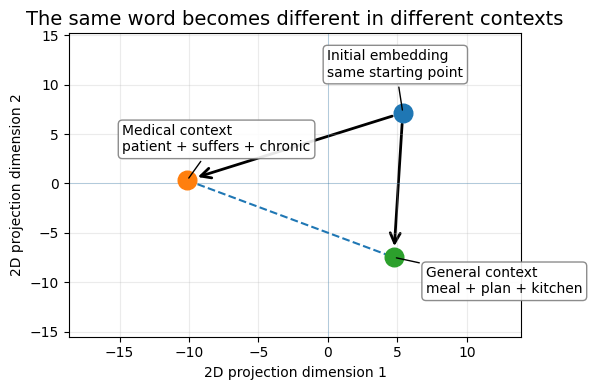

In [21]:
# Convert vectors to numpy
start_vector = medical_initial.squeeze(0).cpu().numpy()
medical_end_vector = medical_final.squeeze(0).cpu().numpy()
general_end_vector = general_final.squeeze(0).cpu().numpy()

vectors = np.vstack([start_vector, medical_end_vector, general_end_vector])

# Reduce 768D vectors to 2D for visualization
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

start = vectors_2d[0]
medical_end = vectors_2d[1]
general_end = vectors_2d[2]

final_similarity = cosine_similarity(medical_final, general_final).item()

fig, ax = plt.subplots(figsize=(6, 4))

# Plot points
ax.scatter(start[0], start[1], s=180, zorder=3)
ax.scatter(medical_end[0], medical_end[1], s=180, zorder=3)
ax.scatter(general_end[0], general_end[1], s=180, zorder=3)

# Draw arrows
arrow_medical = FancyArrowPatch(
    posA=start,
    posB=medical_end,
    arrowstyle="->",
    mutation_scale=18,
    linewidth=2,
    shrinkA=8,
    shrinkB=8,
)

arrow_general = FancyArrowPatch(
    posA=start,
    posB=general_end,
    arrowstyle="->",
    mutation_scale=18,
    linewidth=2,
    shrinkA=8,
    shrinkB=8,
)

ax.add_patch(arrow_medical)
ax.add_patch(arrow_general)

# Add dashed line between the two contextual endpoints
ax.plot(
    [medical_end[0], general_end[0]],
    [medical_end[1], general_end[1]],
    linestyle="--",
    linewidth=1.5,
)

# Dynamic label offsets
x_values = vectors_2d[:, 0]
y_values = vectors_2d[:, 1]

x_range = max(x_values.max() - x_values.min(), 0.1)
y_range = max(y_values.max() - y_values.min(), 0.1)

label_box = dict(
    boxstyle="round,pad=0.3",
    facecolor="white",
    edgecolor="gray",
    alpha=0.9,
)

ax.annotate(
    "Initial embedding\nsame starting point",
    xy=start,
    xytext=(start[0] - 0.35 * x_range, start[1] + 0.25 * y_range),
    arrowprops=dict(arrowstyle="-", linewidth=1),
    bbox=label_box,
    fontsize=10,
)

ax.annotate(
    "Medical context\npatient + suffers + chronic",
    xy=medical_end,
    xytext=(medical_end[0] - 0.3 * x_range, medical_end[1] + 0.20 * y_range),
    arrowprops=dict(arrowstyle="-", linewidth=1),
    bbox=label_box,
    fontsize=10,
)

ax.annotate(
    "General context\nmeal + plan + kitchen",
    xy=general_end,
    xytext=(general_end[0] + 0.15 * x_range, general_end[1] - 0.25 * y_range),
    arrowprops=dict(arrowstyle="-", linewidth=1),
    bbox=label_box,
    fontsize=10,
)

# Add margins so labels do not overlap with figure edges
x_pad = 0.55 * x_range
y_pad = 0.55 * y_range

ax.set_xlim(x_values.min() - x_pad, x_values.max() + x_pad)
ax.set_ylim(y_values.min() - y_pad, y_values.max() + y_pad)

ax.axhline(0, linewidth=0.5, alpha=0.4)
ax.axvline(0, linewidth=0.5, alpha=0.4)

ax.set_title("The same word becomes different in different contexts", fontsize=14)
ax.set_xlabel("2D projection dimension 1")
ax.set_ylabel("2D projection dimension 2")

ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### What does this visualization show?

- Both examples contain the same token: `headache`.
- Before context, both start from the same lookup embedding.
- After BERT reads the sentences, the representations move in different directions.
- This is the key idea of contextual embeddings: the same word can receive a different vector depending on the sentence.
